In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Generate realistic dataset for machine learning
np.random.seed(42)
n_users = 1500

data = {
    'Age': np.random.randint(18, 65, n_users),
    'Monthly_Meditation_Mins': np.random.randint(10, 150, n_users),
    'Sleep_Tracking_Days': np.random.randint(0, 30, n_users),
}
df = pd.DataFrame(data)

# Inject logical churn patterns (e.g., lower meditation/sleep habits = higher probability of churning)
churn_prob = 1 / (1 + np.exp(0.03 * (df['Monthly_Meditation_Mins'] + df['Sleep_Tracking_Days'] * 2) - 2.5))
df['Churned'] = np.where(np.random.rand(n_users) < churn_prob, 1, 0)

# 2. Separate features (X) and target/label (y)
X = df[['Age', 'Monthly_Meditation_Mins', 'Sleep_Tracking_Days']]
y = df['Churned']

# 3. Train/Test Split (80% training data, 20% validation testing data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions on unseen test data
y_pred = model.predict(X_test)

# 6. Display Performance Metrics
print("🎯 Model Training Complete!")
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

🎯 Model Training Complete!
Overall Model Accuracy: 72.00%


/tmp/ipykernel_11523/3030535074.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


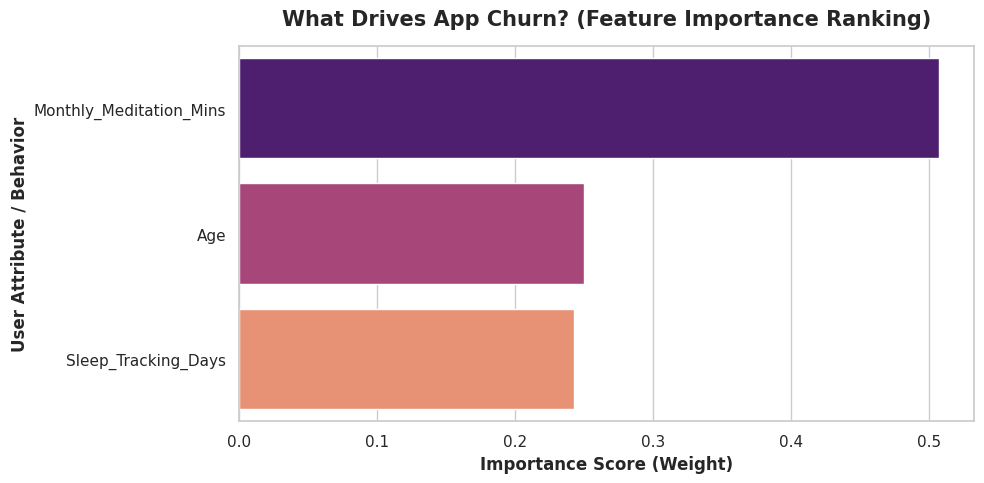

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the trained random forest model
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a clean DataFrame for plotting
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_importance,
    x='Importance',
    y='Feature',
    palette='magma'
)

# 4. Customizing layout
plt.title('What Drives App Churn? (Feature Importance Ranking)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Weight)', fontsize=12, fontweight='bold')
plt.ylabel('User Attribute / Behavior', fontsize=12, fontweight='bold')
plt.tight_layout()

# Render chart
plt.show()